<div style="background:linear-gradient(135deg,#78350f 0%,#d97706 55%,#f59e0b 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 49 · Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Manufacturing Defects: the Binomial 🏭</div>
  <div style="font-size:15px;color:#fff7ed;max-width:740px;line-height:1.6">Each batch is 50 parts, and each part passes or fails inspection. The count of defects per batch is the binomial distribution. We estimate the defect rate, fit the binomial, and size the risk of a bad batch.</div>
  <div style="margin-top:16px;font-size:13px;color:#fed7aa">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup &amp; data

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
from math import comb
AMBER="#d97706"; TEAL="#0d9488"; INK="#1a2138"; GRID="#e6e9f2"; PINK="#db2777"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_csv("../../data/manufacturing_qc_inspections.csv")
except FileNotFoundError: df = pd.read_csv(BASE+"manufacturing_qc_inspections.csv")
print("loaded:", df.shape)
df.head()

loaded: (1000, 5)


,batch_id,inspection_date,inspector_id,batch_size,defective_count
0,BATCH_50000,2026-01-01,INS_04,50,1
1,BATCH_50001,2026-01-01,INS_04,50,4
2,BATCH_50002,2026-01-01,INS_04,50,3
3,BATCH_50003,2026-01-01,INS_03,50,1
4,BATCH_50004,2026-01-01,INS_01,50,1


<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 1 · n TRIALS, ONE RATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">From the part rate to the batch count</div>
<div style="color:#4a5578;margin-top:6px">A binomial counts the successes in n independent Bernoulli trials. Here n=50 parts per batch, and a 'success' is a defect. The per-part defect rate p is the total defects over the total parts.</div>
</div>

In [2]:
n = int(df["batch_size"].iloc[0])
p = df["defective_count"].sum() / (n*len(df))
print(f"batches            : {len(df):,}")
print(f"batch size n        : {n}")
print(f"per-part defect rate p = {p:.4f}  ({p:.2%})")
print(f"Binomial mean  = n p        = {n*p:.3f}")
print(f"Binomial variance = n p(1-p) = {n*p*(1-p):.3f}")
print(f"observed mean defects/batch  = {df.defective_count.mean():.3f}  (matches n p)")

batches            : 1,000
batch size n        : 50
per-part defect rate p = 0.0385  (3.85%)
Binomial mean  = n p        = 1.927
Binomial variance = n p(1-p) = 1.853
observed mean defects/batch  = 1.927  (matches n p)


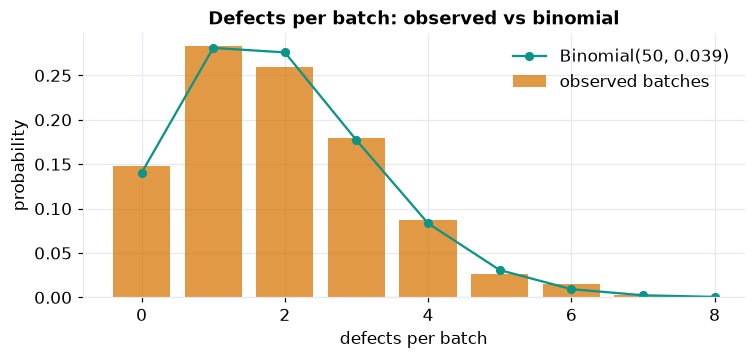

In [3]:
fig,ax=plt.subplots(figsize=(7,3.4))
kmax=int(df.defective_count.max())+1; k=np.arange(0,kmax+1)
obs=df.defective_count.value_counts(normalize=True).sort_index()
ax.bar(obs.index, obs.values, color=AMBER, alpha=0.75, label="observed batches", width=0.8)
ax.plot(k, stats.binom.pmf(k,n,p),"o-",color=TEAL,ms=5,label=f"Binomial(50, {p:.3f})")
ax.set_xlabel("defects per batch"); ax.set_ylabel("probability"); ax.set_title("Defects per batch: observed vs binomial"); ax.legend()
plt.tight_layout(); plt.show()

The binomial PMF, built from C(50, k) p&#7503;(1&minus;p)&#8311;&#8315;&#7503;, lands almost perfectly on the observed batch counts. The combinatorial term C(50, k) counts the ways k defects can fall among 50 parts, the counting from Chapter 32 at work.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 2 · THE RISK OF A BAD BATCH</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">CDF for cumulative boundaries</div>
<div style="color:#4a5578;margin-top:6px">Quality control cares about thresholds. The CDF P(X <= 2) gives the chance a batch passes a 'no more than 2 defects' rule; its complement is the reject risk.</div>
</div>

In [4]:
for thr in [0,1,2,3,5]:
    print(f"P(X <= {thr}) = {stats.binom.cdf(thr,n,p):.4f}   P(X > {thr}) = {stats.binom.sf(thr,n,p):.4f}")
print()
# exact hand calculation of P(X=2) via the formula, to confirm scipy
k=2; manual = comb(n,k)*p**k*(1-p)**(n-k)
print(f"manual P(X=2) = C(50,2) p^2 (1-p)^48 = {manual:.4f}  (scipy {stats.binom.pmf(2,n,p):.4f})")

P(X <= 0) = 0.1401   P(X > 0) = 0.8599
P(X <= 1) = 0.4210   P(X > 1) = 0.5790
P(X <= 2) = 0.6969   P(X > 2) = 0.3031
P(X <= 3) = 0.8738   P(X > 3) = 0.1262
P(X <= 5) = 0.9878   P(X > 5) = 0.0122

manual P(X=2) = C(50,2) p^2 (1-p)^48 = 0.2758  (scipy 0.2758)


About **70%** of batches have 2 or fewer defects, so a "reject if more than 2" rule would scrap roughly **30%** of production, expensive. The hand-computed P(X=2) using C(50,2) matches SciPy exactly, confirming the model. Tuning the threshold trades scrap rate against quality, a decision the CDF makes precise.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 3 · SIMULATE A PRODUCTION RUN</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Long-run defect totals</div>
<div style="color:#4a5578;margin-top:6px">Stack many batches and the daily defect total is a sum of binomials, itself approximately normal by the CLT. We simulate a production run to see the spread of outcomes.</div>
</div>

In [5]:
rng = np.random.default_rng(49)
sim = rng.binomial(n, p, size=200_000)
print(f"simulated mean defects/batch = {sim.mean():.3f}  (theory {n*p:.3f})")
print(f"P(a batch is defect-free)    = {stats.binom.pmf(0,n,p):.4f}  ({(sim==0).mean():.4f} simulated)")
run=30; daily=rng.binomial(n,p,size=(100_000,run)).sum(axis=1)
print(f"over {run} batches/day: expected total = {run*n*p:.1f}, P(>80 defects) = {(daily>80).mean():.4f}")

simulated mean defects/batch = 1.924  (theory 1.927)
P(a batch is defect-free)    = 0.1401  (0.1410 simulated)
over 30 batches/day: expected total = 57.8, P(>80 defects) = 0.0023


A defect-free batch happens about **14%** of the time, P(X=0) = (1&minus;p)&#8309;&#8304;. Across a 30-batch day the total defects center near 58 with predictable spread, letting the plant set staffing and rework budgets from the distribution rather than from a guess.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Case closed</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">Defects per fixed batch are binomial. We estimated the per-part rate p, fit Binomial(50, p) to the data, used the CDF to size the reject risk (P(X&le;2) = 0.70), and simulated production totals. The combinatorial C(n,k) is what turns a per-part rate into a batch-level forecast.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>